# Contingency Analysis in Transmission Grids

Contingency analysis is a critical process in power system operations used to assess the impact of potential failures (e.g., line outages) on grid stability and reliability. It helps operators prepare for unexpected events by simulating scenarios such as N-1 or N-2 contingencies, where one or more components are removed from service. This analysis ensures that the grid can continue to operate within safe limits even under stressed conditions.

---

## Dataset Generation and Model Evaluation

The dataset used in this study originates from the Texas transmission grid, which includes approximately 2,000 nodes. Using the contingency mode of the `gridfm-datakit`, we simulated N-2 contingencies by removing up to two transmission lines at a time. For each scenario, we first solved the optimal power flow (OPF) problem to determine the generation dispatch. Then, we applied the contingency by removing lines and re-solved the power flow to observe the resulting grid state.

This process generated around 100,000 unique scenarios. Our model, **GENCO**, was trained on this dataset to predict power flow outcomes. For demonstration purposes, we selected a subsample of 181 scenarios. The `gridfm-datakit` also computed DC power flow results, enabling a comparison between GENCO predictions and traditional DC power flow estimates, specifically in terms of line loading accuracy.

All predictions are benchmarked against the ground truth obtained from AC power flow simulations. Additionally, we analyze bus voltage violations, which GridFM can predict but are not captured by the DC solver, highlighting GENCO’s enhanced capabilities in modeling grid behavior.


In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from contingency_utils import *

## Load Data

We load both the ground truth and predicted values of the power flow solution. The predictions are generated using the `gridfm-graphkit` CLI:

```bash
gridfm-graphkit predict ...
```

We then merge the datasets using `scenario` and `bus` as keys, allowing us to align the predicted and actual values for each grid state and bus.

In [3]:
root_pred_folder = "../data/k_2/"
prediction_dir = "test_lineloadings"
label_plot = "GENCO_Texas"

In [4]:
preds = pd.read_parquet(os.path.join(root_pred_folder, "preds/Texas2k_case1_2016summerpeak_predictions.parquet"))
bus_data = pd.read_parquet(os.path.join(root_pred_folder, "raw/bus_data.parquet/da40e377c2264d5c86a668c9e28ca566-0.parquet"))
branch_data = pd.read_parquet(os.path.join(root_pred_folder, "raw/branch_data.parquet/7d82df9ae566416c80af53c81e1aac68-0.parquet"))

In [ ]:
# n-2 on ccc
preds = pd.read_parquet("/dccstor/gridfm/mlflow_alban_contingency/504276166362365184/45509e8f71a3455689720d8e7a5b259b/artifacts/test/Texas2k_case1_2016summerpeak_predictions.parquet")
bus_data = pd.read_parquet("/dccstor/gridfm/powermodels_data/v4/texas_contingency/test_2/Texas2k_case1_2016summerpeak/raw/bus_data.parquet/scenario_partition=0/da40e377c2264d5c86a668c9e28ca566-0.parquet")
branch_data = pd.read_parquet("/dccstor/gridfm/powermodels_data/v4/texas_contingency/test_2/Texas2k_case1_2016summerpeak/raw/branch_data.parquet/scenario_partition=0/7d82df9ae566416c80af53c81e1aac68-0.parquet")

In [5]:
# Filter data to use same scenarios
bus_scenarios = bus_data['scenario'].values
filtered_preds = preds[preds['scenario'].isin(bus_scenarios)]
preds_scenarios = filtered_preds['scenario'].values
filtered_bus_data = bus_data[bus_data['scenario'].isin(preds_scenarios)]
filtered_branch_data = branch_data[branch_data['scenario'].isin(preds_scenarios)] 

In [6]:
# Create one df for GT and preds
pf_node = filtered_preds.merge(filtered_bus_data, on=["scenario", "bus"], how="left")
pf_node.head()

,scenario,bus,pd_mw,qd_mvar,vm_pu_target,va_target,pg_mw_target,qg_mvar_target,is_pq,is_pv,...,PQ,PV,REF,vn_kv,min_vm_pu,max_vm_pu,GS,BS,Va_dc,Pg_dc
0,119,0,19.222311,6.101731,0.977767,0.276036,0.00,0.000000,1,0,...,1.0,0.0,0.0,115.0,0.9,1.1,0.0,0.0,21.707588,0.00
1,119,1,15.598279,4.462708,1.013294,0.393017,0.00,0.000000,1,0,...,1.0,0.0,0.0,115.0,0.9,1.1,0.0,0.0,29.208739,0.00
2,119,2,0.000000,0.000000,0.985133,0.457996,0.00,0.000000,1,0,...,1.0,0.0,0.0,115.0,0.9,1.1,0.0,0.0,31.995320,0.00
3,119,3,0.000000,0.000000,0.991531,0.439531,158.25,-5.724123,0,1,...,0.0,1.0,0.0,230.0,0.9,1.1,0.0,0.0,30.876392,158.25
4,119,4,0.000000,0.000000,0.997940,0.466987,0.00,0.000000,1,0,...,1.0,0.0,0.0,115.0,0.9,1.1,0.0,0.0,33.316213,0.00


In [7]:
# Correct Vm and Va values for PV and REF buses
pf_node["Vm_pred_corrected"] = pf_node["vm_pu"]
pf_node["Va_pred_corrected"] = pf_node["va"]
pf_node.loc[pf_node.PV == 1, "Vm_pred_corrected"] = pf_node.loc[pf_node.PV == 1, "Vm"]
pf_node.loc[pf_node.REF == 1, "Va_pred_corrected"] = pf_node.loc[pf_node.REF == 1, "Va"]

pf_node["Vm_dc"] = 1 # Create column set values to 1

pf_node["Vm_dc_corrected"] = pf_node["Vm_dc"]
pf_node["Va_dc_corrected"] = pf_node["Va_dc"]

pf_node.loc[pf_node.PV == 1, "Vm_dc_corrected"] = pf_node.loc[pf_node.PV == 1, "Vm"]
pf_node.loc[pf_node.REF == 1, "Va_dc_corrected"] = pf_node.loc[pf_node.REF == 1, "Va"]

/tmp/ipykernel_551505/2200566357.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.99153102 0.99902949 0.99783707 ... 0.9952515  0.99819908 0.99608818]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  pf_node.loc[pf_node.PV == 1, "Vm_pred_corrected"] = pf_node.loc[pf_node.PV == 1, "Vm"]
/tmp/ipykernel_551505/2200566357.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.99153102 0.99902949 0.99783707 ... 0.9952515  0.99819908 0.99608818]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pf_node.loc[pf_node.PV == 1, "Vm_dc_corrected"] = pf_node.loc[pf_node.PV == 1, "Vm"]


In [8]:
# All angles in degrees
pf_node['Va_pred_corrected'] = np.rad2deg(pf_node['Va_pred_corrected'])
pf_node['va_target'] = np.rad2deg(pf_node['va_target'])
pf_node

,scenario,bus,pd_mw,qd_mvar,vm_pu_target,va_target,pg_mw_target,qg_mvar_target,is_pq,is_pv,...,max_vm_pu,GS,BS,Va_dc,Pg_dc,Vm_pred_corrected,Va_pred_corrected,Vm_dc,Vm_dc_corrected,Va_dc_corrected
0,119,0,19.222311,6.101731,0.977767,15.815712,0.00,0.000000,1,0,...,1.1,0.0,0.0000,21.707588,0.00,0.977736,15.325487,1,1.000000,21.707588
1,119,1,15.598279,4.462708,1.013294,22.518227,0.00,0.000000,1,0,...,1.1,0.0,0.0000,29.208739,0.00,1.013282,22.104565,1,1.000000,29.208739
2,119,2,0.000000,0.000000,0.985133,26.241213,0.00,0.000000,1,0,...,1.1,0.0,0.0000,31.995320,0.00,0.985135,25.679169,1,1.000000,31.995320
3,119,3,0.000000,0.000000,0.991531,25.183296,158.25,-5.724123,0,1,...,1.1,0.0,0.0000,30.876392,158.25,0.991531,24.619114,1,0.991531,30.876392
4,119,4,0.000000,0.000000,0.997940,26.756367,0.00,0.000000,1,0,...,1.1,0.0,0.0000,33.316213,0.00,0.997946,26.277237,1,1.000000,33.316213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361995,18,1995,0.000000,0.000000,0.998727,-2.830099,0.00,0.000000,1,0,...,1.1,0.0,0.0000,-0.383660,0.00,0.998534,-2.780723,1,1.000000,-0.383660
361996,18,1996,0.000000,0.000000,0.993264,-5.236807,0.00,0.000000,1,0,...,1.1,0.0,0.0000,-2.437228,0.00,0.993077,-5.160418,1,1.000000,-2.437228
361997,18,1997,0.000000,0.000000,0.998666,-1.415278,0.00,0.000000,1,0,...,1.1,0.0,0.0000,0.503776,0.00,0.998116,-1.382692,1,1.000000,0.503776
361998,18,1998,0.000000,0.000000,1.002820,-3.406559,0.00,0.000000,1,0,...,1.1,0.0,0.9089,-1.231174,0.00,1.002363,-3.370332,1,1.000000,-1.231174


## Compute branch current and line loading

In [9]:
#### Create loadings

loadings = []
loadings_pred = []
loadings_dc = []

results = {}

for scenario_idx in tqdm(pf_node.scenario.unique()):
    pf_node_scenario = pf_node[pf_node.scenario == scenario_idx]
    branch_data_scenario = filtered_branch_data[filtered_branch_data.scenario == scenario_idx]

    flags = ['gt', 'pred', 'dc']
    for f in flags:
        
        # Get power flows - of all branches that are 0 and 1
        pf, qf, pt, qt = compute_branch_powers_vectorized(branch_data_scenario, pf_node_scenario, sn_mva=100.0, flag=f)

        results[f] = {
        'pf': pf,
        'qf': qf,
        'pt': pt,
        'qt': qt
        }
        
        s_from = np.sqrt(results[f]['pf'] ** 2  + results[f]['qf'] ** 2)
        s_to = np.sqrt(results[f]['pt']** 2  + results[f]['qt'] ** 2)

        #branch_removed_idx = branch_data_scenario[branch_data_scenario['br_status']==0].idx.values.astype(int)
        
        rated_branches = branch_data_scenario[(branch_data_scenario["rate_a"] > 0)].copy()
        rate_a = rated_branches["rate_a"].to_numpy()  

        # check if line flow is 0
        #print(s_from[branch_removed_idx])

        # Loading = max(S_from, S_to) / rate_a
        loading = np.maximum(s_from, s_to) / rate_a
    
        if f == "gt":
            loadings.append(loading)
        elif f == "pred":
            loadings_pred.append(loading)
        elif f == "dc": 
            loadings_dc.append(loading)

loadings = np.array(loadings)
loadings_pred = np.array(loadings_pred)
loadings_dc = np.array(loadings_dc)


 36%|███▌      | 65/181 [00:01<00:01, 61.81it/s]

100%|██████████| 181/181 [00:02<00:00, 61.99it/s]


In [10]:
loadings = loadings.flatten()
loadings_pred = loadings_pred.flatten()
loadings_dc = loadings_dc.flatten()

overloadings_mask = (loadings > 1.00)
overloadings_pred_mask = (loadings_pred > 1.00)
overloadings_dc_mask = (loadings_dc > 1.00)

In [11]:
overloadings = loadings[overloadings_mask == True]
overloadings_pred = loadings_pred[overloadings_pred_mask == True]
overloadings_dc = loadings_dc[overloadings_dc_mask == True]

## Compute metrics for overloading classification for GridFM and DC PF
- Below are the results of GENCO for overloading classification (HGNS version)
- Ground truth is AC PF.

In [12]:
TP_genco, FP_genco, TN_genco, FN_genco = compute_cm_metrics(
    overloadings_mask, overloadings_pred_mask, prediction_dir, label_plot
)

Accuracy: 1.000
Confusion Matrix:
TP: 28, FP: 43, TN: 582747, FN: 2
GENCO
TPR: 0.933 (percentage of overloadings correctly predicted)
FPR: 0.000 (percentage of non-overloadings predicted as overloadings)
TNR: 1.00
FNR: 0.07


- Below are the results of DC PF for overloading classification
- Ground truth is AC PF.
- We use a threshold of 0.95 to make sure we identify all overloads

In [13]:
TP_dc, FP_dc, TN_dc, FN_dc = compute_cm_metrics(
    overloadings_mask, overloadings_dc_mask, "DC", label_plot
)

Accuracy: 0.999
Confusion Matrix:
TP: 29, FP: 822, TN: 581968, FN: 1
GENCO
TPR: 0.967 (percentage of overloadings correctly predicted)
FPR: 0.001 (percentage of non-overloadings predicted as overloadings)
TNR: 1.00
FNR: 0.03


## Histogram of true line loadings

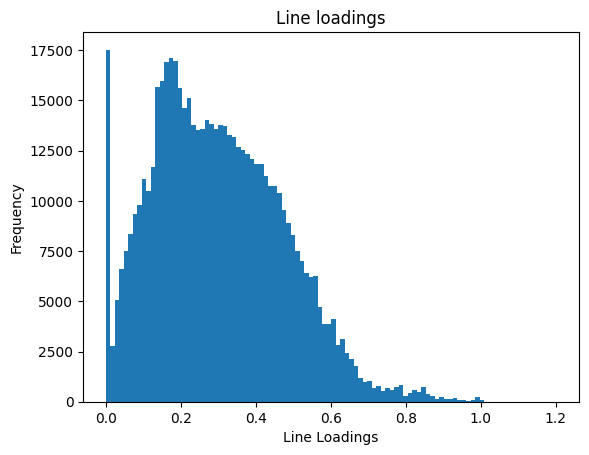

In [14]:
plt.hist(loadings, bins=100)
plt.xlabel("Line Loadings")
plt.ylabel("Frequency")
plt.title("Line loadings")
# log scale
plt.savefig(f"loadings_histogram_{prediction_dir}.png")
plt.show()

## Predicted vs True line loading

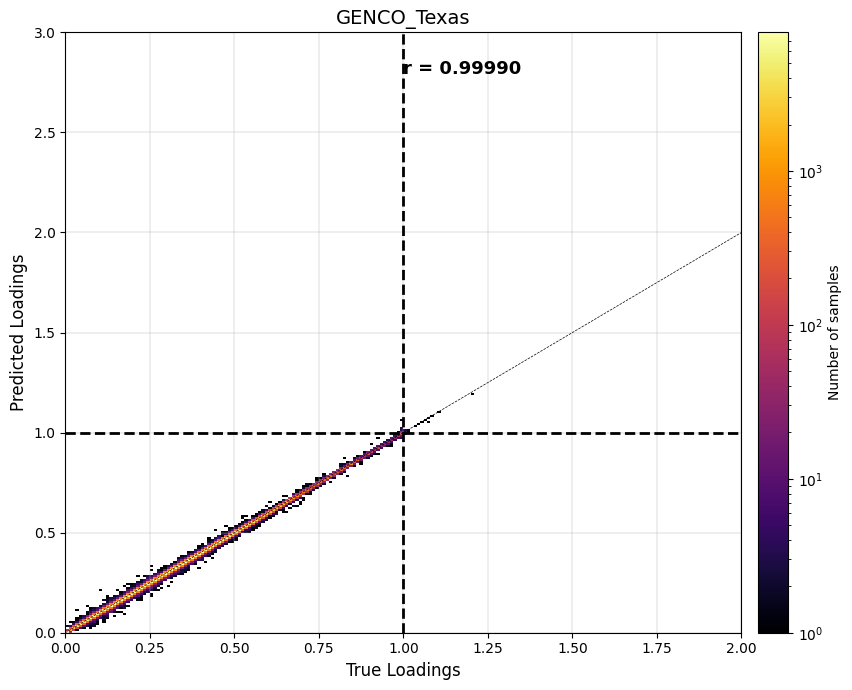

In [15]:
true_vals = loadings
gfm_vals = loadings_pred
dc_vals = loadings_dc

plot_mass_correlation_density(true_vals, gfm_vals, prediction_dir, label_plot)

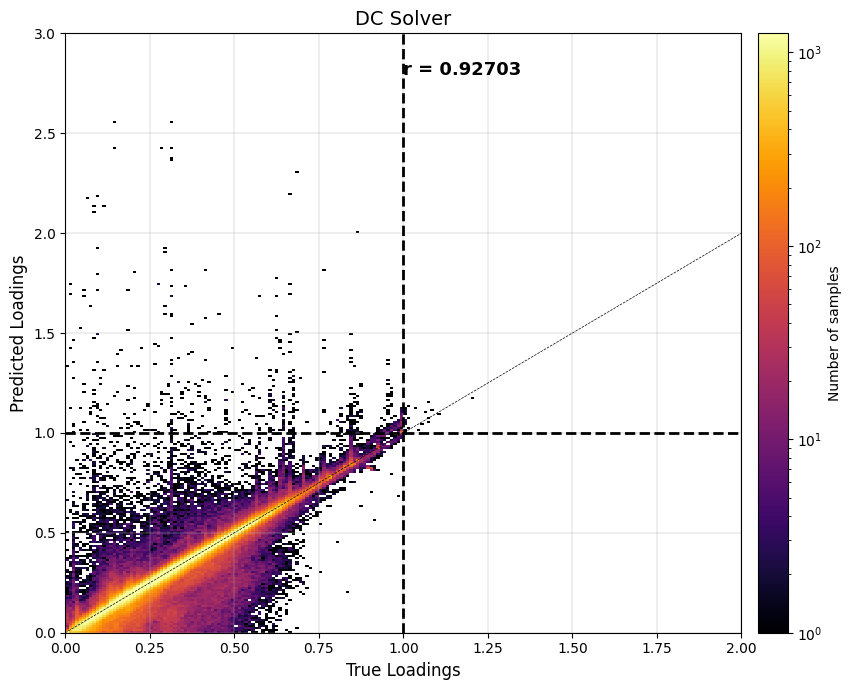

In [16]:
plot_mass_correlation_density(true_vals, dc_vals, "DC", "DC Solver")

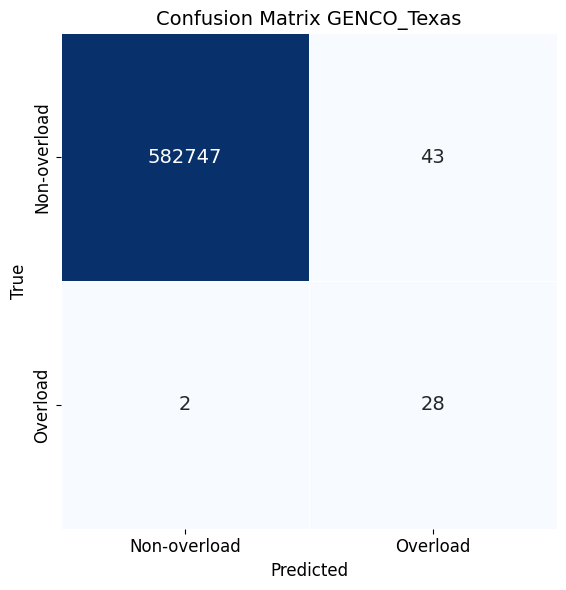

In [17]:
plot_cm(TN_genco, FP_genco, FN_genco, TP_genco, prediction_dir, label_plot)

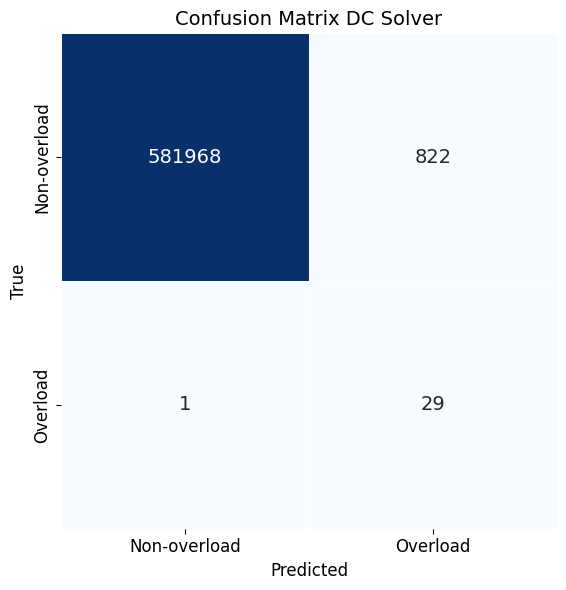

In [18]:
plot_cm(TN_dc, FP_dc, FN_dc, TP_dc, "DC", "DC Solver")

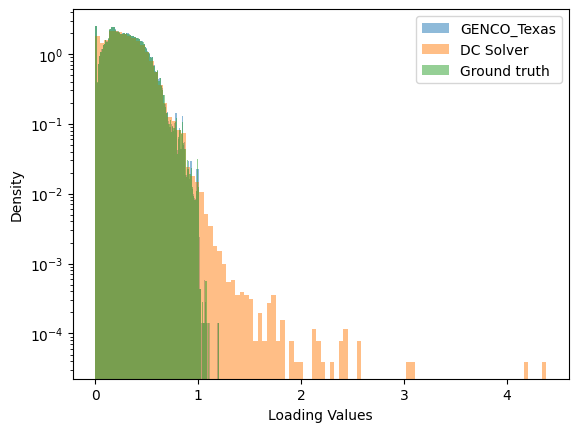

In [19]:
# Histograms of loadings
plot_loading_predictions(
    loadings_pred,
    loadings_dc,
    loadings,
    prediction_dir,
    label_plot,
)

/dccstor/gridfm/tamara/modelling/updates/new_eval/gridfm-graphkit/venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/dccstor/gridfm/tamara/modelling/updates/new_eval/gridfm-graphkit/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


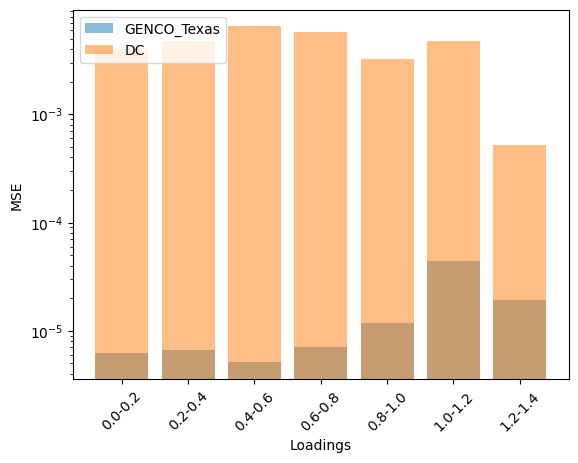

In [20]:
# make bar plot of wrongly classified loadings for different bins
bins = np.arange(0, 2.2, 0.2)
mse_pred = []
mse_dc = []
for i in range(len(bins) - 1):
    idx_in_bins = (loadings > bins[i]) & (
        loadings< bins[i + 1]
    )
    mse_pred.append(
        np.mean(
            (
                loadings_pred[idx_in_bins]
                - loadings[idx_in_bins]
            )
            ** 2
        )
    )
    mse_dc.append(
        np.mean(
            (
                loadings_dc[idx_in_bins]
                - loadings[idx_in_bins]
            )
            ** 2
        )
    )
# labels
labels = [f"{bins[i]:.1f}-{bins[i + 1]:.1f}" for i in range(len(bins) - 1)]
plt.bar(labels, mse_pred, label=label_plot, alpha=0.5)
plt.bar(labels, mse_dc, label="DC", alpha=0.5)
plt.legend()
plt.xlabel("Loadings")
plt.ylabel("MSE")
# y log scale
plt.yscale("log")
# rotate x labels
plt.xticks(rotation=45)
plt.savefig(f"loading_mse_{prediction_dir}.png")
plt.show()

## Voltage violations

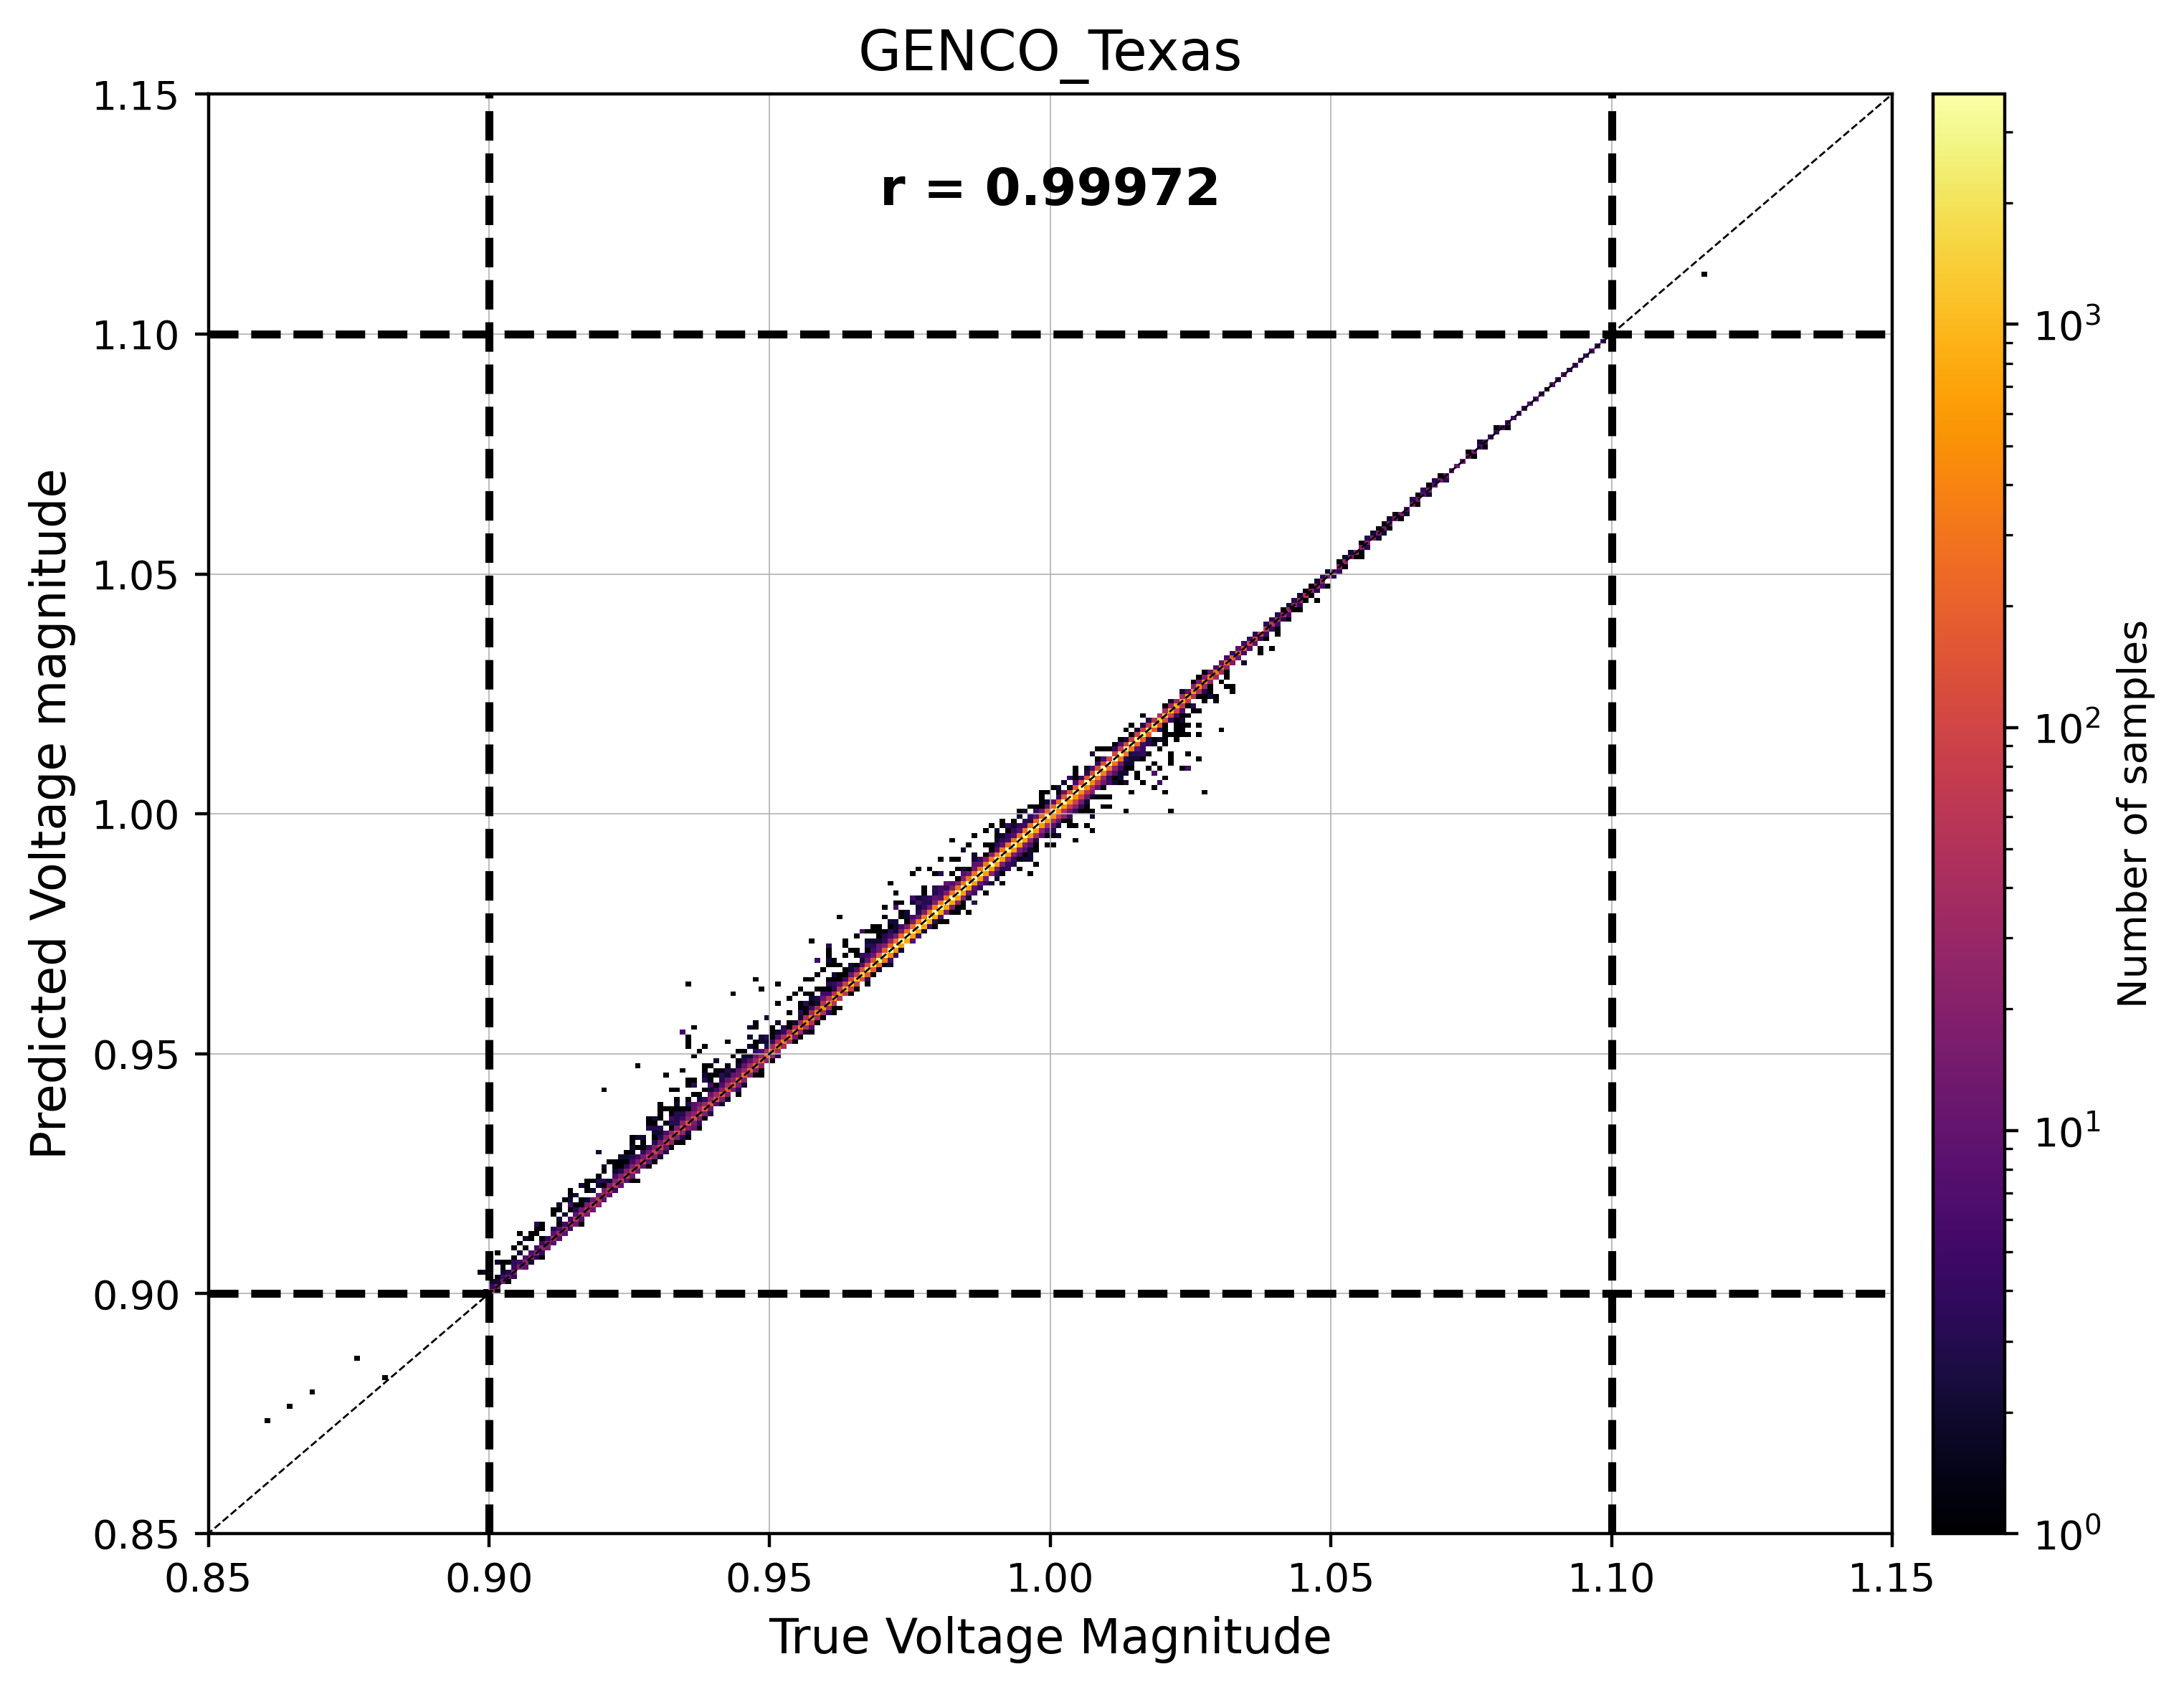

In [21]:
plot_mass_correlation_density_voltage(pf_node, prediction_dir, label_plot)

In [22]:
# Compute CM for Vm and Vm predicted
vm_violation_mask = (pf_node["Vm"] > 1.00)
vm_pred_violation_mask = (pf_node["Vm_pred_corrected"] > 1.00)

In [23]:
TP_genco_vm, FP_genco_vm, TN_genco_vm, FN_genco_vm = compute_cm_metrics(
    vm_violation_mask, vm_pred_violation_mask, "Vm violations", label_plot
)

Accuracy: 0.997
Confusion Matrix:
TP: 104198, FP: 272, TN: 256748, FN: 782
GENCO
TPR: 0.993 (percentage of overloadings correctly predicted)
FPR: 0.001 (percentage of non-overloadings predicted as overloadings)
TNR: 1.00
FNR: 0.01


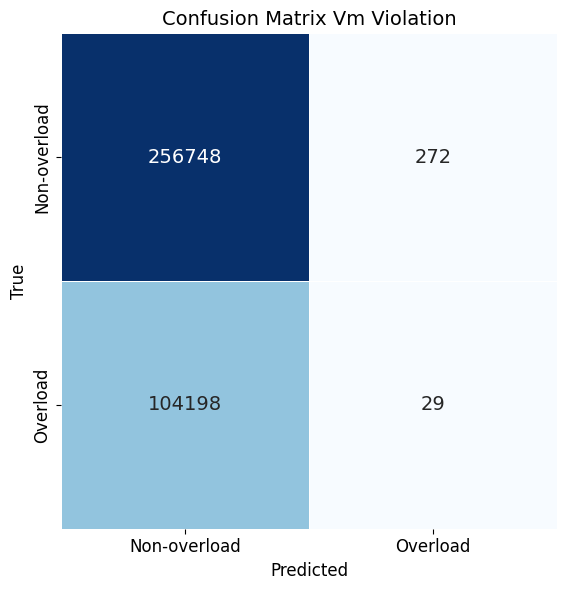

In [24]:
plot_cm(TN_genco_vm, FP_genco_vm, TP_genco_vm, TP_dc, "VM", "Vm Violation")
